## Introduction

for the intro week of the fontys AI for Society Minor we have been tasked with exploring the titanic survival rate dataset, using a model to test and evaluate, and exploring our findings

## Domain understanding
For this task a domain understanding is not necassary, this is because 1) the findings cannot contribute to anything 2) even if the accuracy is off it is not contributing to anything

## Data
the data provided is tabular data in a csv file, the data also appears to be cleaned. also the output seems to be preporcessed since its already in numerical value

In [ ]:
import pandas
df = pandas.read_csv('titanic.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1313 entries, 0 to 1312
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pnumber    1313 non-null   int64  
 1   pclass     1313 non-null   object 
 2   survived   1313 non-null   int64  
 3   name       1313 non-null   object 
 4   age        633 non-null    float64
 5   embarked   821 non-null    object 
 6   home.dest  754 non-null    object 
 7   room       77 non-null     object 
 8   ticket     69 non-null     object 
 9   boat       347 non-null    object 
 10  sex        1313 non-null   object 
dtypes: float64(1), int64(2), object(8)
memory usage: 113.0+ KB


In [2]:
df.head()

,pnumber,pclass,survived,name,age,embarked,home.dest,room,ticket,boat,sex
0,1,1st,1,"Allen, Miss Elisabeth Walton",29.0000,Southampton,"St Louis, MO",B-5,24160 L221,2,female
1,2,1st,0,"Allison, Miss Helen Loraine",2.0000,Southampton,"Montreal, PQ / Chesterville, ON",C26,NaN,NaN,female
2,3,1st,0,"Allison, Mr Hudson Joshua Creighton",30.0000,Southampton,"Montreal, PQ / Chesterville, ON",C26,NaN,-135,male
3,4,1st,0,"Allison, Mrs Hudson J.C. (Bessie Waldo Daniels)",25.0000,Southampton,"Montreal, PQ / Chesterville, ON",C26,NaN,NaN,female
4,5,1st,1,"Allison, Master Hudson Trevor",0.9167,Southampton,"Montreal, PQ / Chesterville, ON",C22,NaN,11,male


As mentioned above and displayed currently is the dataset that will be used, we can see the output for survived has already been preprocessed and overal the dataset is clean. However i will still make a heatmap to see which features contribute to the output most so i can cut down my features if needed.

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

because some of the features are still in text form (string) i will preporcess some of the features that makes sense to turn into a int.

In [4]:
import sklearn.preprocessing
encoder = sklearn.preprocessing.LabelEncoder()
df['Sex'] = encoder.fit_transform(df['sex'])
df['Pclass'] = encoder.fit_transform(df['pclass'])

In [5]:
#ensuring that the preprocessing steps are correct and the data is ready for analysis
df.head(500)

,pnumber,pclass,survived,name,age,embarked,home.dest,room,ticket,boat,sex,Sex,Pclass
0,1,1st,1,"Allen, Miss Elisabeth Walton",29.0000,Southampton,"St Louis, MO",B-5,24160 L221,2,female,0,0
1,2,1st,0,"Allison, Miss Helen Loraine",2.0000,Southampton,"Montreal, PQ / Chesterville, ON",C26,NaN,NaN,female,0,0
2,3,1st,0,"Allison, Mr Hudson Joshua Creighton",30.0000,Southampton,"Montreal, PQ / Chesterville, ON",C26,NaN,-135,male,1,0
3,4,1st,0,"Allison, Mrs Hudson J.C. (Bessie Waldo Daniels)",25.0000,Southampton,"Montreal, PQ / Chesterville, ON",C26,NaN,NaN,female,0,0
4,5,1st,1,"Allison, Master Hudson Trevor",0.9167,Southampton,"Montreal, PQ / Chesterville, ON",C22,NaN,11,male,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,2nd,0,"Matthews, Mr William John",30.0000,Southampton,"St Austall, Cornwall",NaN,NaN,NaN,male,1,1
496,497,2nd,0,"Maybery, Mr Frank H.",20.0000,Southampton,"Weston-Super-Mare / Moose Jaw, SK",NaN,NaN,NaN,male,1,1
497,498,2nd,0,"McCrae, Mr Arthur Gordon",45.0000,Southampton,"Sydney, Australia",NaN,NaN,-209,male,1,1
498,499,2nd,0,"McCrie, Mr James Matthew",NaN,Southampton,"Sarnia, ON",NaN,NaN,NaN,male,1,1


In [6]:
df.drop(['pclass', 'sex'], axis=1, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1313 entries, 0 to 1312
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pnumber    1313 non-null   int64  
 1   survived   1313 non-null   int64  
 2   name       1313 non-null   object 
 3   age        633 non-null    float64
 4   embarked   821 non-null    object 
 5   home.dest  754 non-null    object 
 6   room       77 non-null     object 
 7   ticket     69 non-null     object 
 8   boat       347 non-null    object 
 9   Sex        1313 non-null   int64  
 10  Pclass     1313 non-null   int64  
dtypes: float64(1), int64(4), object(6)
memory usage: 113.0+ KB


<Axes: >

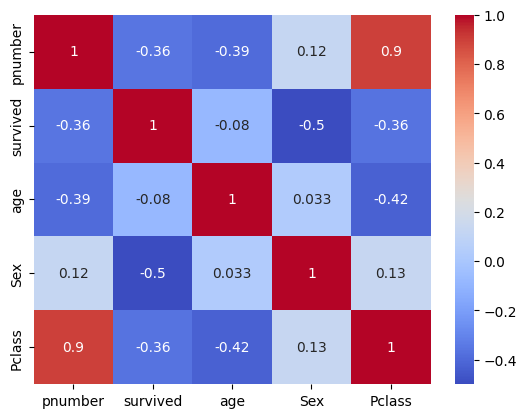

In [7]:
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

now from the heatmap if we look along the survived column and row we can see that sex, pclass, pnumber had the most correlation compared to the other features. if we also look a bit closer PClass and pnumber had a 0.9 correlation so we can either choose to drop one of them because they are so similiar or keep them. just because this is a draft i chose to keep both but i will be dropping age since it had little correlation to whether a passenger survived or not 

In [ ]:
features = (['Sex', 'Pclass', 'pnumber'])
target = 'survived'
x = df[features]
y = df[target]
# to note i dropped the other columns because most have missing values which would have made the model
# less accurate and more prone to overfitting. I also dropped the columns that 
# were not relevant to the model such as name, ticket, cabin, and embarked.

In [9]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(x_train, y_train)
score = model.score(x_test, y_test)
print("Accuracy:", score)


Accuracy: 0.7262357414448669


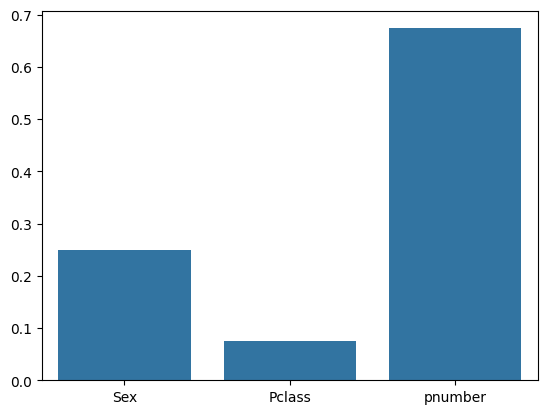

In [10]:
plot = sns.barplot(y=model.feature_importances_, x=features)

from the graph above we can see passenger number had the most influence over the results followed by sex and passenger class

In [12]:
from sklearn.metrics import classification_report
target_names = ['Did Not Survive', 'Survived']

print("Train set:")
predictions = model.predict(x_train)
report = classification_report(y_train, predictions, target_names=target_names)
print(report)

print("Test set:")
predictions = model.predict(x_test)
report = classification_report(y_test, predictions, target_names=target_names)
print(report)

Train set:
                 precision    recall  f1-score   support

Did Not Survive       1.00      1.00      1.00       696
       Survived       1.00      1.00      1.00       354

       accuracy                           1.00      1050
      macro avg       1.00      1.00      1.00      1050
   weighted avg       1.00      1.00      1.00      1050

Test set:
                 precision    recall  f1-score   support

Did Not Survive       0.78      0.80      0.79       168
       Survived       0.63      0.60      0.61        95

       accuracy                           0.73       263
      macro avg       0.70      0.70      0.70       263
   weighted avg       0.72      0.73      0.72       263



The train set data is way better than the test set meaning the model overfitted quite a bit, before i draw a conclusion i will make a second itteration with only 2 features

In [13]:
features1 = (['Sex', 'Pclass'])
target1 = 'survived'
x1 = df[features1]
y1 = df[target1]
x1_train, x1_test, y1_train, y1_test = train_test_split(x1, y1, test_size=0.2, random_state=42)
model1 = RandomForestClassifier(n_estimators=100, random_state=42)
model1.fit(x1_train, y1_train)
score1 = model1.score(x1_test, y1_test)
print("Accuracy:", score1)

Accuracy: 0.8174904942965779


In [14]:
print("Train set:")
predictions = model1.predict(x1_train)
report = classification_report(y1_train, predictions, target_names=target_names)
print(report)

print("Test set:")
predictions = model1.predict(x1_test)
report = classification_report(y1_test, predictions, target_names=target_names)
print(report)

Train set:
                 precision    recall  f1-score   support

Did Not Survive       0.79      0.97      0.87       696
       Survived       0.90      0.51      0.65       354

       accuracy                           0.81      1050
      macro avg       0.85      0.74      0.76      1050
   weighted avg       0.83      0.81      0.80      1050

Test set:
                 precision    recall  f1-score   support

Did Not Survive       0.78      0.99      0.87       168
       Survived       0.96      0.52      0.67        95

       accuracy                           0.82       263
      macro avg       0.87      0.75      0.77       263
   weighted avg       0.85      0.82      0.80       263



Here the model did not overfit and was trained on less features, i can theorize that the first model potentially learned a pattern which caused it to overfit

## Findings

Comparing the first to second model we can see the Second model didn't overfit From the minor changes in the features we can conclude that in the first itteration the model learn't a pattern, took the lazy way to learn and overfitted. Also we can see from the scoring that the second itteration had a better accuracy (if we look at the test set) We can presume that having Pclass and Pnumber was a bit redundent which made the first itteration terrible in comparison to the second. This backed by
1) The precision being 85% meaning 85% of the models predictions were actually correct
2) The Recall meaning it caught 82% of positive cases
3) Overall better F1 Score which is a combination of the two mentioned above giving a overal view of how the model did